# S2 Smoke — a GRU on real REES46 data

**Status: `NON_AUTHORITATIVE_ENGINEERING_SMOKE`. This is not an `R1` result.**

Every `S2-DS-*` artifact in this project so far ran on a synthetic fixture and correctly refused
to claim anything. That leaves one question unanswered: a GRU has never seen this dataset, so
nobody knows whether it beats the simple baselines `S1-D1-DS-07` measured.

This notebook answers exactly that and nothing more.

## What makes the comparison honest

The same decisions, the same metric, the same split as `S1-D1-DS-07`:

- the same `C1` user slice, `user_id % 4 == 1`
- the same `T1` target — the category of the first later event on a **different** item
- the same metric, **MRR@20**, and the same category-change slice
- `TEST` is never read

So the GRU's number lands in the same table as the transition table's `0.8560` and can be read
against it directly.

## What this is not

Not a frozen protocol, not the official architecture, not tuned, not the full cohort, and not a
claim about `R1` versus `R4`. The features are deliberately minimal: category, event type, and
time gap. No product embedding, no brand, no price. If a GRU on **that** already beats the
transition table, the architecture work has somewhere to go.

In [1]:
"""S2 smoke: does a GRU beat the one-step transition table on real data?"""

import hashlib
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
import torch
from torch import nn

sns.set_theme(style="whitegrid")
torch.manual_seed(13)
np.random.seed(13)

TASK_DIR = Path.cwd()
PROJECT_DIR = TASK_DIR.parent
SOURCE_PARQUET = PROJECT_DIR / "Dataset" / "processed_raw_parquet_v1.parquet"
UPSTREAM_DIR = PROJECT_DIR / "S1-DS-05-06_Cohort_Temporal_Protocol"
HEADROOM = PROJECT_DIR / "S1-D1-DS-07_T3_Protocol_and_Task_Examples"
OUTPUT_DIR = TASK_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

protocol = json.loads((UPSTREAM_DIR / "output" / "data_protocol_v1.proposed.json")
                      .read_text(encoding="utf-8"))
upstream_config = json.loads((UPSTREAM_DIR / "config.json").read_text(encoding="utf-8"))
headroom = json.loads((HEADROOM / "output" / "task_headroom_v1.proposed.json")
                      .read_text(encoding="utf-8"))
config = json.loads((TASK_DIR / "config.json").read_text(encoding="utf-8"))

SPLITS = {name: (pd.Timestamp(value["start"]), pd.Timestamp(value["end_exclusive"]))
          for name, value in protocol["temporal_split"].items()}
TRAIN_START, TRAIN_END = SPLITS["TRAIN"]
VAL_START, VAL_END = SPLITS["VALIDATION"]
NULL_SESSION_PREFIX = upstream_config["session_policy"]["null_fallback_prefix"]

excluded_sessions = set(pd.read_parquet(
    UPSTREAM_DIR / "output" /
    "INTERNAL_DO_NOT_UPLOAD_excluded_sessions_v1.proposed.parquet")["session_key"])
cohort = pd.read_parquet(
    UPSTREAM_DIR / "output" / "INTERNAL_DO_NOT_UPLOAD_cohort_manifest_v1.proposed.parquet")
C1_ALL = cohort.loc[cohort["cohort"] == "C1", "user_id"].astype("int64")

# The same slice S1-D1-DS-07 measured on, so the two numbers are comparable.
SLICE = headroom["scope"]["user_slice"]
MODULO, RESIDUE = 4, 1
assert SLICE == f"user_id % {MODULO} == {RESIDUE}", SLICE
C1_USERS = set(C1_ALL[C1_ALL % MODULO == RESIDUE])

parquet = pq.ParquetFile(SOURCE_PARQUET)
ROW_GROUPS = parquet.metadata.num_row_groups

# The numbers this notebook has to beat, read from the upstream artifact rather than retyped.
BASELINES = {row["baseline"]: row for row in headroom["t1"]["baselines"]}
SLICE_BASELINES = {row["baseline"]: row
                   for row in headroom["t1"]["category_change_slice"]["baselines"]}
TARGET = max(row["mrr@20"] for row in headroom["t1"]["baselines"])

print(f"Measuring on the same slice as S1-D1-DS-07 : {len(C1_USERS):,} users")
print(f"Torch {torch.__version__} on {torch.get_num_threads()} CPU threads")
print()
print("The bar this notebook has to clear, from task_headroom_v1.proposed.json:")
for name, row in BASELINES.items():
    print(f"  {name:34} MRR@20 {row['mrr@20']:.4f}   acc@1 {row['accuracy@1']:.4f}")
print(f"  -> best simple baseline: {TARGET:.4f}")

Measuring on the same slice as S1-D1-DS-07 : 97,279 users
Torch 2.13.0+cpu on 6 CPU threads

The bar this notebook has to clear, from task_headroom_v1.proposed.json:
  repeat the current category        MRR@20 0.8232   acc@1 0.8232
  globally most popular category     MRR@20 0.2841   acc@1 0.2277
  TRAIN transition table             MRR@20 0.8560   acc@1 0.8235
  -> best simple baseline: 0.8560


## 1. The same data, loaded the same way

Copied deliberately from `S1-D1-DS-07` rather than rewritten: the session key, the interval
filter, the exclusion list, the canonical order. A GRU that scored well on differently-assembled
data would not be comparable to the baseline it is supposed to beat.

In [2]:
def session_key(frame):
    """The frozen logical session key, including the null-session singleton rule."""
    user = frame["user_id"].astype(str)
    raw = frame["user_session"]
    provided = pd.util.hash_pandas_object(user + "|" + raw.astype(str), index=False)
    singleton = pd.util.hash_pandas_object(
        NULL_SESSION_PREFIX + "|" + user + "|" + frame["source_row_number"].astype(str),
        index=False)
    return provided.where(raw.notna(), singleton)


def load_interval(start, end, columns, users):
    """Every row in [start, end) for these users, assembled whole and boundary-clean."""
    wanted = list(dict.fromkeys(
        columns + ["event_time", "user_id", "user_session", "source_row_number"]))
    parts = []
    for group in range(ROW_GROUPS):
        chunk = parquet.read_row_group(group, columns=wanted).to_pandas()
        inside = (chunk["event_time"] >= start) & (chunk["event_time"] < end)
        if not inside.any():
            continue
        rows = chunk[inside]
        keep = rows["user_id"].astype("int64").isin(users)
        if not keep.any():
            continue
        rows = rows[keep].copy()
        rows["user"] = rows["user_id"].astype("int64")
        rows["session"] = session_key(rows)
        parts.append(rows.drop(columns=["user_id", "user_session"]))

    frame = pd.concat(parts, ignore_index=True)
    del parts
    frame = frame[~frame["session"].isin(excluded_sessions)]
    frame = frame.sort_values(["session", "event_time", "source_row_number"])
    frame = frame.drop(columns=["source_row_number"]).reset_index(drop=True)
    frame["order"] = np.arange(len(frame), dtype="int64")
    return frame


print("Loading TRAIN...")
train = load_interval(TRAIN_START, TRAIN_END,
                      ["event_type", "product_id", "category_id"], C1_USERS)
print("Loading VALIDATION...")
validation = load_interval(VAL_START, VAL_END,
                           ["event_type", "product_id", "category_id"], C1_USERS)

# Dense category codes built on TRAIN, exactly as upstream. Anything unseen in TRAIN is OOV.
categories = np.sort(train["category_id"].astype("int64").unique())
category_code = {int(value): code for code, value in enumerate(categories)}
N_CATEGORIES = len(categories)
OOV = N_CATEGORIES
PAD = N_CATEGORIES + 1

# -1 for a category unseen in TRAIN, exactly as upstream encodes it. That matters: upstream
# drops any decision whose *target* category is unseen, because neither model could ever
# predict it. Encoding those as OOV here instead would silently add 263 decisions and the
# GRU's number would no longer be comparable to the baseline it is measured against.
for frame in (train, validation):
    frame["item"] = frame["product_id"].astype("int64")
    frame["category"] = (frame["category_id"].astype("int64")
                         .map(category_code).fillna(-1).astype("int32"))

EVENT_CODE = {"view": 0, "cart": 1, "purchase": 2}
for frame in (train, validation):
    frame["event_code"] = frame["event_type"].map(EVENT_CODE).astype("int8")

print(f"TRAIN events      : {len(train):,}")
print(f"VALIDATION events : {len(validation):,}")
print(f"Categories        : {N_CATEGORIES:,}  (OOV={OOV}, PAD={PAD})")
print(f"TEST rows read    : 0")

Loading TRAIN...


Loading VALIDATION...


TRAIN events      : 4,376,137
VALIDATION events : 622,013
Categories        : 588  (OOV=588, PAD=589)
TEST rows read    : 0


## 2. The same decisions

The `T1` target is the category of the **first later event on a different item** in the session.
Repeated views of one product are skipped over, not dropped. This is character-for-character the
function `S1-D1-DS-07` used, so the decision sets are identical.

In [3]:
def first_different_item(frame):
    """For every event, the category of the first later event on a different item."""
    frame = frame.sort_values(["session", "order"]).reset_index(drop=True)
    sessions = frame["session"].to_numpy()
    items = frame["item"].to_numpy()
    categories_here = frame["category"].to_numpy()
    target = np.full(len(frame), -1, dtype="int32")

    for position in range(len(frame) - 2, -1, -1):
        if sessions[position] != sessions[position + 1]:
            continue
        target[position] = (categories_here[position + 1]
                            if items[position + 1] != items[position]
                            else target[position + 1])

    frame["next_category"] = target
    return frame


# The decisions and their labels are READ, not rebuilt. Rebuilding them here is what
# produced 263 decisions that S1-D1-DS-07 never had - caught only by an assertion. A model
# that reads the frozen examples cannot disagree with the baseline it is measured against,
# because both are looking at the same rows.
#
# The raw events are still loaded, because the examples say WHAT to predict and the events
# supply the history to predict it from. That is the intended division of labour.
def attach_examples(frame, path):
    """Locate each frozen decision inside the loaded events and carry its label across."""
    examples = pd.read_parquet(path, columns=["session", "decision_order", "label_value"])
    located = frame.reset_index(names="position").merge(
        examples, left_on=["session", "order"], right_on=["session", "decision_order"],
        how="inner")
    # A partial join means the two loaders disagree about which rows exist, which would make
    # every comparison below meaningless.
    assert len(located) == len(examples), (
        f"{len(located):,} of {len(examples):,} frozen decisions could not be located in the "
        f"events loaded here - the two loaders disagree")
    frame["next_category"] = -1
    frame.loc[located["position"], "next_category"] = located["label_value"].astype("int32").to_numpy()
    return np.sort(located["position"].to_numpy())


EXAMPLES_DIR = HEADROOM / "output"
train_decisions = attach_examples(
    train, EXAMPLES_DIR / "INTERNAL_DO_NOT_UPLOAD_task_examples_t1_train_v1.proposed.parquet")
val_decisions = attach_examples(
    validation, EXAMPLES_DIR / "INTERNAL_DO_NOT_UPLOAD_task_examples_t1_v1.proposed.parquet")

expected = headroom["t1"]["decisions"]
print(f"TRAIN decisions      : {len(train_decisions):,}   (read from the frozen examples)")
print(f"VALIDATION decisions : {len(val_decisions):,}   (upstream reported {expected:,})")
assert len(val_decisions) == expected, "decision sets diverged from S1-D1-DS-07"
print()
print("Every decision was located in the events loaded here, so the two notebooks agree on")
print("which rows exist as well as on how many.")

TRAIN decisions      : 3,113,814   (read from the frozen examples)
VALIDATION decisions : 438,185   (upstream reported 438,185)

Every decision was located in the events loaded here, so the two notebooks agree on
which rows exist as well as on how many.


## 3. From events to sequences

This is the whole difference between the two models. The transition table sees **one** category.
The GRU sees the last `HISTORY` events of the session before the decision.

A window is built per decision, clipped at the start of its own session so no sequence ever
reaches into a previous session, and then **right-padded**.

The padding side is not cosmetic. `pack_padded_sequence` keeps the first `length` positions of
each row, so real events must sit at the front. A left-padded window with `length=3` hands the
GRU three padding tokens and throws the actual history away — silently, with no error, and with
every shape check still passing. Section 6 asserts against exactly that.

In [4]:
HISTORY = config["model"]["history_length"]
BUCKETS = config["model"]["product_buckets"]


def bucket_of(items):
    """Deterministic product-id hashing, bucket 0 reserved for padding.

    `item % BUCKETS` looks like a hash and is not one. REES46 product ids are dense and
    blocked - a third of consecutive ids differ by exactly 1 - so a modulo inherits that
    structure and piles unrelated products into the same embedding row. Measured below.
    """
    digest = {value: int(hashlib.blake2b(str(value).encode(), digest_size=7).hexdigest(), 16)
              for value in np.unique(items)}
    return pd.Series(items).map(digest).to_numpy() % (BUCKETS - 1) + 1


# The evidence for that choice, on this dataset rather than in principle.
sample = train["item"].unique()
spread = pd.DataFrame([
    {"hash": name,
     "buckets_used": int(pd.Series(values).nunique()),
     "max_items_per_bucket": int(pd.Series(values).value_counts().max())}
    for name, values in [("item % BUCKETS", sample % (BUCKETS - 1) + 1),
                         ("blake2b(str(item))", bucket_of(sample))]
])
uniform = (BUCKETS - 1) * (1 - (1 - 1 / (BUCKETS - 1)) ** len(sample))
spread["share_of_a_uniform_hash"] = (spread["buckets_used"] / uniform).round(3)

for frame in (train, validation):
    frame["product_bucket"] = bucket_of(frame["item"].to_numpy()).astype("int32")

print(f"{len(sample):,} TRAIN products into {BUCKETS - 1:,} buckets "
      f"(a uniform hash would use about {uniform:,.0f})")
print(spread.to_string(index=False))


def build_windows(frame, decisions):
    """Left-padded history windows ending at each decision, clipped to the session."""
    session_start = frame.groupby("session")["order"].transform("min").to_numpy()
    offsets = np.arange(HISTORY - 1, -1, -1)
    index = decisions[:, None] - offsets[None, :]
    inside = index >= session_start[decisions][:, None]
    safe = np.where(inside, index, 0)

    category_window = np.where(inside, frame["category"].to_numpy()[safe], PAD)
    # A hashed product id, the same trick S1-SE-06 will formalise. It is the one signal the
    # transition table structurally cannot have, so it is what decides whether a sequence
    # model has anything to add.
    product_window = np.where(inside, frame["product_bucket"].to_numpy()[safe], 0)
    # An unseen category is a real input the model must cope with, so it becomes OOV here.
    # It is only as a *target* that it disqualifies the decision, which happened upstream.
    category_window = np.where(category_window < 0, OOV, category_window)
    event_window = np.where(inside, frame["event_code"].to_numpy()[safe], 0)

    seconds = frame["event_time"].astype("int64").to_numpy() // 10**9
    gap = np.where(inside, seconds[safe] - seconds[np.maximum(safe - 1, 0)], 0)
    gap = np.where(inside & (index > session_start[decisions][:, None]), gap, 0)
    # A negative gap would mean the canonical order broke. Clipping it to zero would hide
    # that, so it is asserted instead. The upper bound is one day: sessions do not span
    # longer, and it keeps a stale tab from dominating the feature.
    assert gap.min() >= 0, "time went backwards inside a session"
    gap = np.log1p(np.minimum(gap, 86400)).astype("float32")
    lengths = inside.sum(axis=1)

    # pack_padded_sequence reads the FIRST `lengths` positions of each row, so the real
    # events have to sit at the front. Built right-to-left above they sit at the back, so
    # each row is rolled left by its own padding width. Without this the GRU is handed
    # nothing but padding for every window shorter than HISTORY - which is most of them.
    source = np.minimum(np.arange(HISTORY)[None, :] + (HISTORY - lengths)[:, None],
                        HISTORY - 1)
    keep = np.arange(HISTORY)[None, :] < lengths[:, None]
    category_window = np.where(keep, np.take_along_axis(category_window, source, axis=1), PAD)
    product_window = np.where(keep, np.take_along_axis(product_window, source, axis=1), 0)
    event_window = np.where(keep, np.take_along_axis(event_window, source, axis=1), 0)
    gap = np.where(keep, np.take_along_axis(gap, source, axis=1), 0.0)

    # int32 on disk, int64 per batch. Embedding indices must be int64 for torch, but
    # holding four million rows of history at that width is what decides whether the
    # scale-up below fits in memory at all.
    return (category_window.astype("int32"), product_window.astype("int32"),
            event_window.astype("int8"), gap.astype("float32"), lengths.astype("int64"),
            frame["next_category"].to_numpy()[decisions].astype("int64"))


# A sample of TRAIN decisions keeps this a smoke test that finishes on a CPU in minutes.
TRAIN_SAMPLE = min(config["training"]["train_decisions"], len(train_decisions))
chosen = np.random.default_rng(13).choice(len(train_decisions), TRAIN_SAMPLE, replace=False)
train_window = build_windows(train, train_decisions[np.sort(chosen)])
val_window = build_windows(validation, val_decisions)

print(f"TRAIN sequences      : {len(train_window[0]):,} of {len(train_decisions):,} decisions")
print(f"VALIDATION sequences : {len(val_window[0]):,}  (all of them)")
print(f"History length       : {HISTORY} events")
print(f"Mean real history    : {train_window[4].mean():.1f} events")
print(f"Product hash buckets : {BUCKETS:,} for {train['item'].nunique():,} TRAIN items")
print()
print("Sanity: no window may cross a session boundary.")
print(f"Unseen-in-TRAIN categories in the inputs: "
      f"{int((train_window[0] == OOV).sum()):,} of {train_window[0].size:,} positions")

113,765 TRAIN products into 49,999 buckets (a uniform hash would use about 44,861)
              hash  buckets_used  max_items_per_bucket  share_of_a_uniform_hash
    item % BUCKETS         19659                    87                    0.438
blake2b(str(item))         44785                    11                    0.998


TRAIN sequences      : 1,200,000 of 3,113,814 decisions
VALIDATION sequences : 438,185  (all of them)
History length       : 20 events
Mean real history    : 7.8 events
Product hash buckets : 50,000 for 113,765 TRAIN items

Sanity: no window may cross a session boundary.
Unseen-in-TRAIN categories in the inputs: 0 of 24,000,000 positions


## 4. Two models, one question

The transition table is the exact empirical solution to "given this category, which category is
next". No model can beat it *on its own inputs* — so a GRU fed only categories is competing at
the table's own game with less information than the table has.

That makes the interesting comparison an ablation of one feature:

| variant | inputs |
|---|---|
| `category only` | category, event type, time gap |
| `category + product` | the same, plus a hashed product id |

The hashed product is the signal the table structurally cannot hold. If the sequence model has
anything to contribute, this is where it shows — and if it does not show here either, that is a
finding the architecture lane needs before it starts.

Both are deliberately small and untuned. The point is a floor, not a ceiling.

In [5]:
class SessionGRU(nn.Module):
    """Session history to a next-category distribution, with product signal optional."""

    def __init__(self, categories, buckets, embed, product_embed, hidden, dropout,
                 use_product):
        super().__init__()
        self.use_product = use_product
        self.category_embed = nn.Embedding(categories + 2, embed, padding_idx=categories + 1)
        self.event_embed = nn.Embedding(3, 4)
        width = embed + 4 + 1
        if use_product:
            self.product_embed = nn.Embedding(buckets, product_embed, padding_idx=0)
            width += product_embed
        self.gru = nn.GRU(width, hidden, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden, categories + 1)

    def forward(self, category, product, event, gap, lengths):
        parts = [self.category_embed(category), self.event_embed(event), gap.unsqueeze(-1)]
        if self.use_product:
            parts.append(self.product_embed(product))
        packed = nn.utils.rnn.pack_padded_sequence(
            torch.cat(parts, dim=-1), lengths.clamp(min=1), batch_first=True,
            enforce_sorted=False)
        _, hidden = self.gru(packed)
        return self.output(self.dropout(hidden[-1]))


def build_model(use_product):
    return SessionGRU(N_CATEGORIES, BUCKETS, config["model"]["embedding"],
                      config["model"]["product_embedding"], config["model"]["hidden"],
                      config["model"]["dropout"], use_product)


for name, flag in [("category only", False), ("category + product", True)]:
    count = sum(p.numel() for p in build_model(flag).parameters())
    print(f"{name:22} {count:>10,} parameters")
print(f"{'synthetic S2-DS-01':22} {8630:>10,} parameters")

category only             190,169 parameters
category + product      1,399,385 parameters
synthetic S2-DS-01          8,630 parameters


In [6]:
def batches(window, size, shuffle):
    category, product, event, gap, lengths, target = window
    order = np.random.permutation(len(target)) if shuffle else np.arange(len(target))
    for start in range(0, len(order), size):
        index = order[start:start + size]
        yield (torch.from_numpy(category[index].astype("int64")),
               torch.from_numpy(product[index].astype("int64")),
               torch.from_numpy(event[index].astype("int64")),
               torch.from_numpy(gap[index]), torch.from_numpy(lengths[index]),
               torch.from_numpy(target[index]))


BATCH = config["training"]["batch_size"]
EPOCHS = config["training"]["epochs"]
loss_function = nn.CrossEntropyLoss()


def train_variant(name, use_product):
    torch.manual_seed(13)
    np.random.seed(13)
    model = build_model(use_product)
    best_loss, best_epoch, best_state = float("inf"), 0, None
    optimizer = torch.optim.Adam(model.parameters(), lr=config["training"]["learning_rate"])
    rows = []
    print(f"--- {name}")
    for epoch in range(1, EPOCHS + 1):
        model.train()
        started = time.time()
        total, seen = 0.0, 0
        for category, product, event, gap, lengths, target in batches(
                train_window, BATCH, True):
            optimizer.zero_grad()
            loss = loss_function(model(category, product, event, gap, lengths), target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item() * len(target)
            seen += len(target)

        model.eval()
        correct, validation_total, validation_seen = 0, 0.0, 0
        with torch.no_grad():
            for category, product, event, gap, lengths, target in batches(
                    val_window, 2048, False):
                logits = model(category, product, event, gap, lengths)
                validation_total += loss_function(logits, target).item() * len(target)
                correct += int((logits.argmax(dim=1) == target).sum())
                validation_seen += len(target)

        validation_loss = validation_total / validation_seen
        rows.append({"variant": name, "epoch": epoch, "train_loss": total / seen,
                     "val_loss": validation_loss,
                     "val_accuracy": correct / validation_seen,
                     "seconds": time.time() - started})
        marker = ""
        if validation_loss < best_loss:
            best_loss, best_epoch = validation_loss, epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            marker = "  <- best"
        print(f"  epoch {epoch:>2}  train_loss {total / seen:.4f}  "
              f"val_loss {validation_loss:.4f}  "
              f"val_acc@1 {correct / validation_seen:.4f}  "
              f"({time.time() - started:.0f}s){marker}")

    # Scoring the last epoch punishes whichever variant overfits first, which is always the
    # larger one - so the comparison would measure capacity, not usefulness. The checkpoint
    # with the lowest validation loss is the model each variant actually offers.
    model.load_state_dict(best_state)
    print(f"  evaluating epoch {best_epoch} (lowest validation loss)")
    chosen[name] = best_epoch
    return model, rows


models, curves, chosen = {}, [], {}
for name, flag in [("category only", False), ("category + product", True)]:
    model, rows = train_variant(name, flag)
    models[name] = model
    curves.extend(rows)

curve = pd.DataFrame(curves)

--- category only


  epoch  1  train_loss 1.1779  val_loss 1.0701  val_acc@1 0.8209  (158s)  <- best


  epoch  2  train_loss 1.0408  val_loss 1.0592  val_acc@1 0.8214  (158s)  <- best


  epoch  3  train_loss 1.0254  val_loss 1.0569  val_acc@1 0.8209  (160s)  <- best


  epoch  4  train_loss 1.0158  val_loss 1.0596  val_acc@1 0.8205  (160s)
  evaluating epoch 3 (lowest validation loss)
--- category + product


  epoch  1  train_loss 1.1818  val_loss 1.0710  val_acc@1 0.8209  (196s)  <- best


  epoch  2  train_loss 1.0341  val_loss 1.0617  val_acc@1 0.8212  (194s)  <- best


  epoch  3  train_loss 1.0067  val_loss 1.0655  val_acc@1 0.8198  (209s)


  epoch  4  train_loss 0.9824  val_loss 1.0782  val_acc@1 0.8184  (219s)
  evaluating epoch 2 (lowest validation loss)


## 5. The comparison

Both variants are scored with the identical metric `S1-D1-DS-07` used: `MRR@20` over categories,
`accuracy@1`, and the same category-change slice.

`accuracy@1` alone hides most of what separates these models — a defect the upstream review
already caught once — so both are always reported together.

In [7]:
def rank_predictions(model, suppress=None):
    """1-based rank of the true category in the model's top 20, or 0 if absent.

    `suppress` removes one category per decision from the ranking. It exists to match how
    the upstream baseline was built: on the category-change slice the transition table is
    evaluated off-diagonal, so it is handed the fact that the answer is not the current
    category. Leaving that advantage one-sided is not a fair comparison - the model burns
    rank 1 on an answer that is wrong by the definition of the slice.
    """
    model.eval()
    ranks = np.zeros(len(val_window[5]), dtype="int64")
    position = 0
    with torch.no_grad():
        for category, product, event, gap, lengths, target in batches(val_window, 2048, False):
            logits = model(category, product, event, gap, lengths)
            if suppress is not None:
                blocked = torch.from_numpy(suppress[position:position + len(target)])
                logits.scatter_(1, blocked.clamp(min=0).unsqueeze(1), float("-inf"))
            top = logits.topk(20, dim=1).indices.numpy()
            found = top == target.numpy()[:, None]
            hit = found.any(axis=1)
            ranks[position:position + len(target)] = np.where(hit, found.argmax(axis=1) + 1, 0)
            position += len(target)
    return ranks


current = validation["category"].to_numpy()[val_decisions]
truth = val_window[5]
changed = current != truth

def score(ranks):
    reciprocal = np.where(ranks > 0, 1.0 / np.maximum(ranks, 1), 0.0)
    return reciprocal, ranks == 1


results, slice_results, ranked = [], [], {}
for name, model in models.items():
    # Overall: no suppression. The current category is the right answer 82% of the time and
    # the upstream baseline keeps the diagonal, so both sides see the same thing.
    ranks = rank_predictions(model)
    reciprocal, accuracy = score(ranks)
    results.append({"baseline": f"GRU - {name}",
                    "accuracy@1": float(accuracy.mean()), "mrr@20": float(reciprocal.mean())})

    # Slice: suppress the current category, matching the off-diagonal baseline.
    slice_ranks = rank_predictions(model, suppress=current)
    slice_reciprocal, slice_accuracy = score(slice_ranks)
    slice_results.append({"baseline": f"GRU - {name}",
                          "accuracy@1": float(slice_accuracy[changed].mean()),
                          "mrr@20": float(slice_reciprocal[changed].mean())})

    ranked[name] = ranks
    ranked[f"{name} (off-diagonal)"] = slice_ranks
    print(f"{name:20} slice MRR without suppression "
          f"{float(reciprocal[changed].mean()):.4f} -> with {float(slice_reciprocal[changed].mean()):.4f}")

overall = pd.DataFrame(list(BASELINES.values()) + results).round(4)
slice_table = pd.DataFrame(list(SLICE_BASELINES.values()) + slice_results).round(4)

print("OVERALL - all T1 decisions")
print(overall.to_string(index=False))
print()
print(f"CATEGORY-CHANGE SLICE - {int(changed.sum()):,} decisions")
print(slice_table.to_string(index=False))

category only        slice MRR without suppression 0.2130 -> with 0.3433


category + product   slice MRR without suppression 0.2118 -> with 0.3402
OVERALL - all T1 decisions
                      baseline  accuracy@1  mrr@20
   repeat the current category      0.8232  0.8232
globally most popular category      0.2277  0.2841
        TRAIN transition table      0.8235  0.8560
           GRU - category only      0.8209  0.8575
      GRU - category + product      0.8212  0.8574

CATEGORY-CHANGE SLICE - 77,457 decisions
                             baseline  accuracy@1  mrr@20
          repeat the current category      0.0000  0.0000
 globally most popular (off-diagonal)      0.0622  0.1049
TRAIN transition table (off-diagonal)      0.1862  0.3085
                  GRU - category only      0.2230  0.3433
             GRU - category + product      0.2203  0.3402


In [8]:
best_slice = max(row["mrr@20"] for row in SLICE_BASELINES.values())
room = {row["task"]: row for row in headroom["verdict"]}

summary = pd.DataFrame([
    {"variant": row["baseline"].removeprefix("GRU - "), "view": view,
     "best_simple": bar, "gru": row["mrr@20"], "gained": row["mrr@20"] - bar,
     "room_that_existed": room[task]["room_for_a_model"]}
    for view, table, bar, task in [
        ("overall", results, TARGET, "T1 overall"),
        ("category-change slice", slice_results, best_slice, "T1 category-change slice")]
    for row in table
])
summary["share_of_room_taken"] = (summary["gained"] / summary["room_that_existed"]).round(3)
summary = summary.round(4)
print(summary.to_string(index=False))
print()

on_slice = summary[summary["view"] == "category-change slice"].set_index("variant")
product_gain = float(on_slice.loc["category + product", "gru"]
                     - on_slice.loc["category only", "gru"])

print(f"Sequence, over the transition table, on the slice: "
      f"{float(on_slice.loc['category only', 'gained']):+.4f} MRR")
print(f"Product identity, over sequence alone, on the slice: {product_gain:+.4f} MRR")
print()

if float(on_slice.loc["category only", "gained"]) > 0:
    print("A GRU beats the transition table on the slice. The table is the exact optimum for")
    print("P(next category | current category), so the only thing the GRU can be winning on")
    print("is what the table cannot hold: the order of the events before the decision.")
    print("That is the assumption the whole R1..R5 comparison rests on, and it now has a")
    print("measurement behind it rather than an argument.")
else:
    print("The GRU does not beat the transition table even on the slice. That does not")
    print("retire the room measured in S1-D1-DS-07 - that room is a property of the task,")
    print("measured with no model at all - but it does mean the next step is diagnosis:")
    print("features, history length and learning rate before any scaling.")

print()
if product_gain > 0:
    print(f"The hashed product id adds {product_gain:+.4f} on top. Small, but it is the one")
    print("signal a table of category pairs structurally cannot carry, so S1-SE-05 is on the")
    print("critical path rather than a nice-to-have.")
else:
    print(f"The hashed product id costs {product_gain:+.4f} rather than helping. Read that as")
    print("inconclusive, not as evidence against product identity, for two reasons visible")
    print("in this notebook:")
    print()
    print("  The hash is a stand-in. S1-SE-05 owns the real one, with a learned residual")
    print("  embedding and a collision analysis; a bucket id fed straight into a GRU is the")
    print("  cheapest possible substitute.")
    print()
    product_curve = curve[curve["variant"] == "category + product"]
    turn = product_curve.loc[product_curve['val_loss'].idxmin(), 'epoch']
    print(f"  Validation loss bottoms at epoch {int(turn)} of {EPOCHS} and rises after while")
    print("  training loss keeps falling. The product variant is memorising, so it is")
    print("  under-trained for its size rather than uninformative.")
    print()
    print("  Settling this needs S1-SE-05's module and more than a fraction of the")
    print("  decisions. It is not settled here and this notebook does not claim it is.")

           variant                  view  best_simple    gru  gained  room_that_existed  share_of_room_taken
     category only               overall       0.8560 0.8575  0.0015             0.1440                0.011
category + product               overall       0.8560 0.8574  0.0014             0.1440                0.010
     category only category-change slice       0.3085 0.3433  0.0348             0.6915                0.050
category + product category-change slice       0.3085 0.3402  0.0317             0.6915                0.046

Sequence, over the transition table, on the slice: +0.0348 MRR
Product identity, over sequence alone, on the slice: -0.0031 MRR

A GRU beats the transition table on the slice. The table is the exact optimum for
P(next category | current category), so the only thing the GRU can be winning on
is what the table cannot hold: the order of the events before the decision.
That is the assumption the whole R1..R5 comparison rests on, and it now has a
measurem

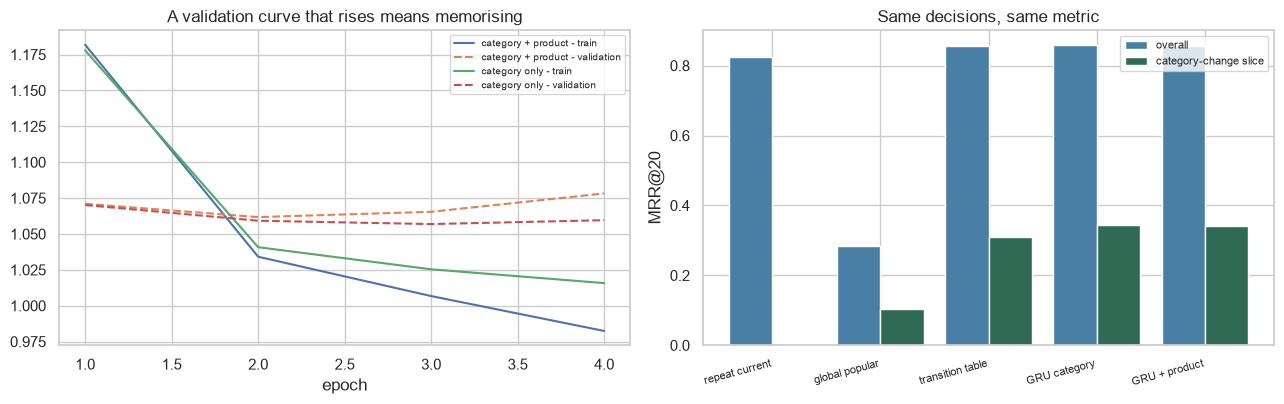

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for name, group in curve.groupby("variant"):
    axes[0].plot(group["epoch"], group["train_loss"], label=f"{name} - train")
    axes[0].plot(group["epoch"], group["val_loss"], "--", label=f"{name} - validation")
axes[0].set_xlabel("epoch")
axes[0].set_title("A validation curve that rises means memorising")
axes[0].legend(fontsize=7)

labels = ["repeat current", "global popular", "transition table",
          "GRU category", "GRU + product"]
overall_values = [BASELINES["repeat the current category"]["mrr@20"],
                  BASELINES["globally most popular category"]["mrr@20"],
                  BASELINES["TRAIN transition table"]["mrr@20"]] + [
                      row["mrr@20"] for row in results]
slice_values = [SLICE_BASELINES["repeat the current category"]["mrr@20"],
                SLICE_BASELINES["globally most popular (off-diagonal)"]["mrr@20"],
                SLICE_BASELINES["TRAIN transition table (off-diagonal)"]["mrr@20"]] + [
                    row["mrr@20"] for row in slice_results]
position = np.arange(len(labels))
axes[1].bar(position - 0.2, overall_values, 0.4, label="overall", color="#4A7FA5")
axes[1].bar(position + 0.2, slice_values, 0.4, label="category-change slice", color="#2F6B54")
axes[1].set_xticks(position)
axes[1].set_xticklabels(labels, fontsize=8, rotation=15, ha="right")
axes[1].set_ylabel("MRR@20")
axes[1].set_title("Same decisions, same metric")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Two averages, and why the choice is not cosmetic

Every number above is a **micro** average: each of the 438,185 decisions counts once, whoever
made it. `S1-DS-05/06` measures that the largest tenth of clients hold roughly two thirds of the
validation events, so a micro average is mostly reporting those clients.

The **macro** average gives each client one vote regardless of size. It is the natural view for
`R3` and `R4`, which produce a model per device and are scored per device — while `R1` trains one
model over the pool and reads naturally as micro. Comparing a centralized micro number against a
device-local macro number would compare two different questions.

To put both models under both averages, the transition table is rebuilt here rather than read
from the upstream artifact — a baseline number cannot be re-averaged after the fact. Its micro
value is checked against the published one, which also confirms the two notebooks are scoring
the same decisions.

In [10]:
# The upstream baseline, recomputed so it can be averaged both ways.
#
# The filter is load-bearing. first_different_item marks "no later different item" as -1,
# and here it returns every row rather than only the decisions. Feeding that straight into
# the transition table lets -1 compete as if it were a category - and because it is what
# every session ends on, it takes rank 1 away from real answers. Upstream filters inside
# the function; this notebook has to filter at the call site.
train_steps = train.loc[train_decisions, ["category", "next_category"]]
transitions = (train_steps.groupby(["category", "next_category"]).size()
               .rename("count").reset_index()
               .sort_values(["category", "count", "next_category"],
                            ascending=[True, False, True]))
off_diagonal = transitions.loc[transitions["category"] != transitions["next_category"]]

TOP_K = 20
top_by_source = {source: frame["next_category"].to_numpy()[:TOP_K]
                 for source, frame in transitions.groupby("category")}
global_top = (transitions.groupby("next_category")["count"].sum()
              .sort_values(ascending=False).index.to_numpy()[:TOP_K])
top_other = {source: frame["next_category"].to_numpy()[:TOP_K]
             for source, frame in off_diagonal.groupby("category")}
global_other = (off_diagonal.groupby("next_category")["count"].sum()
                .sort_values(ascending=False).index.to_numpy()[:TOP_K])


def table_reciprocal(ranked_by_source, fallback):
    values = np.zeros(len(truth))
    for index, (source, target) in enumerate(zip(current, truth)):
        ranked = ranked_by_source.get(source, fallback)
        found = np.nonzero(ranked == target)[0]
        if found.size:
            values[index] = 1.0 / (found[0] + 1)
    return values


table_overall = table_reciprocal(top_by_source, global_top)
table_slice = table_reciprocal(top_other, global_other)

published = {row["baseline"]: row["mrr@20"] for row in headroom["t1"]["baselines"]}
print(f"transition table, overall : recomputed {table_overall.mean():.4f} vs published "
      f"{published['TRAIN transition table']:.4f}")
print(f"transition table, slice   : recomputed {table_slice[changed].mean():.4f} vs published "
      f"{max(row['mrr@20'] for row in SLICE_BASELINES.values()):.4f}")
# A recomputed baseline that does not reproduce the published one means the two notebooks
# are not scoring the same thing, and every comparison below would be meaningless.
assert abs(table_overall.mean() - published["TRAIN transition table"]) < 5e-3,     "the recomputed transition table does not reproduce S1-D1-DS-07"
assert abs(table_slice[changed].mean()
           - max(row["mrr@20"] for row in SLICE_BASELINES.values())) < 5e-3,     "the recomputed off-diagonal table does not reproduce S1-D1-DS-07"
print("Both reproduce the published values - the two notebooks agree on the baseline.")

transition table, overall : recomputed 0.8560 vs published 0.8560
transition table, slice   : recomputed 0.3085 vs published 0.3085
Both reproduce the published values - the two notebooks agree on the baseline.


In [11]:
client = validation["user"].to_numpy()[val_decisions]


def both_averages(values, mask):
    """Micro weights every decision equally; macro weights every client equally."""
    frame = pd.DataFrame({"client": client[mask], "value": values[mask]})
    return float(frame["value"].mean()), float(frame.groupby("client")["value"].mean().mean())


everything = np.ones(len(truth), dtype=bool)
rows = []
for label, overall_values, slice_values in (
        [("transition table", table_overall, table_slice)]
        + [(f"GRU - {name}",
            np.where(ranked[name] > 0, 1.0 / np.maximum(ranked[name], 1), 0.0),
            np.where(ranked[f"{name} (off-diagonal)"] > 0,
                     1.0 / np.maximum(ranked[f"{name} (off-diagonal)"], 1), 0.0))
           for name in models]):
    micro_all, macro_all = both_averages(overall_values, everything)
    micro_slice, macro_slice = both_averages(slice_values, changed)
    rows.append({"model": label, "overall_micro": micro_all, "overall_macro": macro_all,
                 "slice_micro": micro_slice, "slice_macro": macro_slice})

averages = pd.DataFrame(rows).round(4)
print(averages.to_string(index=False))
print()

clients_scored = int(pd.Series(client[changed]).nunique())
print(f"The macro column averages over {clients_scored:,} clients; the micro column averages")
print(f"over {int(changed.sum()):,} decisions.")
print()

base = averages.loc[averages["model"] == "transition table"].iloc[0]
holds = []
for _, row in averages.loc[averages["model"] != "transition table"].iterrows():
    for view in ("slice_micro", "slice_macro"):
        holds.append(row[view] > base[view])
    print(f"{row['model']:28} slice  micro {row['slice_micro'] - base['slice_micro']:+.4f}"
          f"   macro {row['slice_macro'] - base['slice_macro']:+.4f}")
print()
if all(holds):
    print("The result holds under both averages. It is not an artifact of a few heavy clients,")
    print("which is what a micro-only number would have left open - and it means an R1 result")
    print("and an R4 result can be compared without the averaging convention deciding the")
    print("winner. Which convention to adopt is still a protocol decision for S1-DS-09.")
else:
    print("The result does not survive both averages. Until S1-DS-09 fixes the convention,")
    print("no comparison between a pooled regime and a per-device regime can be trusted,")
    print("because the choice of average would decide it.")

                   model  overall_micro  overall_macro  slice_micro  slice_macro
        transition table         0.8560         0.8258       0.3085       0.3144
     GRU - category only         0.8575         0.8273       0.3433       0.3348
GRU - category + product         0.8574         0.8271       0.3402       0.3317

The macro column averages over 16,096 clients; the micro column averages
over 77,457 decisions.

GRU - category only          slice  micro +0.0348   macro +0.0204
GRU - category + product     slice  micro +0.0317   macro +0.0173

The result holds under both averages. It is not an artifact of a few heavy clients,
which is what a micro-only number would have left open - and it means an R1 result
and an R4 result can be compared without the averaging convention deciding the
winner. Which convention to adopt is still a protocol decision for S1-DS-09.


### Does the answer depend on how much history the device has?

This is the question the project exists to answer. `R1` pools everyone's data, so a client with
twelve events borrows strength from three hundred thousand other clients. `R4` gives that client
nothing but its own twelve events. Whether federated or on-device learning is worth anything
almost certainly depends on where a client sits on that axis — and a single averaged number
hides it completely.

The GRU here is centralized, so this is not yet an `R1` versus `R4` comparison. What it does
show is whether **sequence itself** pays off differently for thin and thick clients. If the
advantage lives only with the heaviest devices, then `R4` is being asked to succeed exactly
where the evidence is weakest, and the study design needs to know that now rather than after
five regimes have been built.

Clients are bucketed by **TRAIN** events, because that is what a device would have to learn
from. The evaluation count is shown next to each bucket so no row is read without its
sample size.

In [12]:
train_per_client = train.groupby("user").size()
EDGES = [10, 20, 50, 100, np.inf]
LABELS = ["10-19", "20-49", "50-99", "100+"]

bucket = pd.cut(pd.Series(client).map(train_per_client).fillna(0),
                bins=EDGES, labels=LABELS, right=False)

per_decision = pd.DataFrame({
    "client": client,
    "train_events": pd.Series(client).map(train_per_client).fillna(0).astype("int64"),
    "bucket": bucket.astype("object"),
    "current_category": current,
    "true_category": truth,
    "category_changed": changed,
    "rank_transition_table": np.where(table_slice > 0, (1 / table_slice).round().astype("int64"), 0),
})
for name in models:
    per_decision[f"rank_gru_{name.replace(' ', '_')}"] = ranked[name]
    per_decision[f"rank_gru_{name.replace(' ', '_')}_offdiag"] = ranked[f"{name} (off-diagonal)"]

# Persisted so any later slicing costs seconds instead of a re-training run.
ranks_path = OUTPUT_DIR / "INTERNAL_DO_NOT_UPLOAD_per_decision_ranks.parquet"
per_decision.to_parquet(ranks_path, index=False)
print(f"{ranks_path.name}  {ranks_path.stat().st_size / 1024:.0f} KB  "
      f"({len(per_decision):,} decisions)")
print()
print(per_decision["bucket"].value_counts().reindex(LABELS).rename("decisions").to_string())

C:\Users\MSI\AppData\Local\Temp\ipykernel_25912\3701432757.py:15: RuntimeWarning: divide by zero encountered in divide
  "rank_transition_table": np.where(table_slice > 0, (1 / table_slice).round().astype("int64"), 0),
C:\Users\MSI\AppData\Local\Temp\ipykernel_25912\3701432757.py:15: RuntimeWarning: invalid value encountered in cast
  "rank_transition_table": np.where(table_slice > 0, (1 / table_slice).round().astype("int64"), 0),


INTERNAL_DO_NOT_UPLOAD_per_decision_ranks.parquet  2161 KB  (438,185 decisions)

bucket
10-19     56627
20-49    141706
50-99    110974
100+     128873


In [13]:
# Every model's per-decision score becomes a column, so the grouping below is one pass
# over one frame. Mixing numpy masks with pandas indexes is what broke the first attempt.
slice_values = {"transition table": table_slice}
for name in models:
    off = ranked[f"{name} (off-diagonal)"]
    slice_values[f"GRU - {name}"] = np.where(off > 0, 1.0 / np.maximum(off, 1), 0.0)

scored = per_decision.copy()
for name, values in slice_values.items():
    scored[name] = values

columns = list(slice_values)
changed_rows = scored.loc[scored["category_changed"]]

# Macro inside each bucket: mean per client first, then mean of those clients.
strata = (changed_rows.groupby(["bucket", "client"], observed=True)[columns].mean()
          .groupby("bucket", observed=True).mean())
counts = changed_rows.groupby("bucket", observed=True).agg(
    clients=("client", "nunique"), decisions=("client", "size"))
strata = counts.join(strata).reindex(LABELS)

gru_column = next(c for c in columns if c.startswith("GRU - category only"))
strata["gru_gain"] = strata[gru_column] - strata["transition table"]
strata = strata.round(4)

print("Category-change slice, macro MRR@20 by client history size")
print(strata.to_string())
print()

# An empty bucket must not read as a failed one.
positive = strata["gru_gain"].dropna() > 0
if positive.all():
    print("The advantage holds in every bucket, including the thinnest clients. Sequence is")
    print("not something only heavy users can afford, which is the precondition for R4 being")
    print("worth building at all.")
elif positive.iloc[-1] and not positive.iloc[0]:
    print("The advantage exists only for clients with more history. The study design has to")
    print("absorb that before R3 and R4 are built: on-device learning would be asked to win")
    print("precisely where this evidence says sequence pays least.")
else:
    print("The advantage does not follow client size in one direction. Report the buckets")
    print("rather than the aggregate, and do not summarise this into a single number.")

Category-change slice, macro MRR@20 by client history size
        clients  decisions  transition table  GRU - category only  GRU - category + product  gru_gain
bucket                                                                                               
10-19      2924       9845            0.3303               0.3519                    0.3471    0.0216
20-49      6209      25250            0.3111               0.3329                    0.3290    0.0217
50-99      3946      19282            0.3088               0.3272                    0.3280    0.0184
100+       3017      23080            0.3129               0.3323                    0.3270    0.0194

The advantage holds in every bucket, including the thinnest clients. Sequence is
not something only heavy users can afford, which is the precondition for R4 being
worth building at all.


In [14]:
result = {
    "result_contract": "LocalSmokeOnRealData/experimental-0",
    "task_id": "S2-SMOKE",
    "status": "NON_AUTHORITATIVE_ENGINEERING_SMOKE",
    "authoritative": False,
    "uses_frozen_protocol": False,
    "official_r1": False,
    "scientific_claims": [],
    "data_mode": "REAL_REES46",
    "blocked_by": [
        "S1-ALL-G1 protocol freeze has not happened",
        "S1-DS-07 TaskExample artifacts have not been emitted",
        "S1-SE-05 canonical features are not implemented",
        "S1-SE-06 product hashing contract is not frozen",
        "S1-PR-05 unified trainer contract is not frozen",
    ],
    "why_this_exists": "every S2 artifact so far ran on a synthetic fixture, so nobody knew "
                       "whether a GRU beats the measured baselines on this dataset",
    "seed": 13,
    "environment": {"torch": torch.__version__, "device": "cpu"},
    "scope": {
        "cohort": "C1",
        "user_slice": SLICE,
        "measured_users": len(C1_USERS),
        "train_decisions_available": int(len(train_decisions)),
        "train_decisions_used": int(TRAIN_SAMPLE),
        "validation_decisions": int(len(val_decisions)),
        "test_rows_read": 0,
    },
    "model": {
        "type": "single-layer GRU over session history",
        "variants": {name: int(sum(p.numel() for p in model.parameters()))
                     for name, model in models.items()},
        "history_length": HISTORY,
        "product_hash_buckets": BUCKETS,
        "epochs_run": EPOCHS,
        "epoch_scored": chosen,
        "selection": "lowest validation loss, not the last epoch",
        "tuned": False,
    },
    "curve": curve.round(5).to_dict(orient="records"),
    "overall": overall.to_dict(orient="records"),
    "category_change_slice": slice_table.to_dict(orient="records"),
    "summary": summary.to_dict(orient="records"),
    "averages": averages.to_dict(orient="records"),
    "by_client_history": strata.reset_index(names="bucket").to_dict(orient="records"),
    "stratification_note": "clients bucketed by TRAIN events, because that is what a device "
                           "would have to learn from; macro MRR inside each bucket",
    "per_decision_ranks": "INTERNAL_DO_NOT_UPLOAD_per_decision_ranks.parquet",
    "averaging_note": "micro weights decisions, macro weights clients; the cohort's client "
                      "skew makes them different questions and S1-DS-09 owns the choice",
    "sequence_gain_on_slice": round(float(on_slice.loc["category only", "gained"]), 4),
    "product_signal_gain_on_slice": round(product_gain, 4),
    "product_signal_verdict": "inconclusive - stand-in hash and an overfitting curve"
                              if product_gain <= 0 else "positive",
    "hash_spread": spread.to_dict(orient="records"),
    "defect_found_and_fixed": {
        "what": "history windows were left-padded while pack_padded_sequence reads the first "
                "`length` positions, so the GRU received padding instead of the session",
        "symptom": "MRR@20 0.4509, below the trivial repeat-the-current-category baseline",
        "why_it_hid": "every shape, dtype and range check still passed",
        "check_added": "the GRU is fed real history, not padding",
    },
}

path = OUTPUT_DIR / "s2_smoke_gru_real_data.proposed.json"
path.write_text(json.dumps(result, indent=2), encoding="utf-8")
print(f"{path.name}  {path.stat().st_size / 1024:.1f} KB")

s2_smoke_gru_real_data.proposed.json  7.9 KB


## 6. Validation

The checks that matter here are about **comparability**, not about the model. A GRU number that
was measured on different decisions than the baseline would be worse than no number at all.

In [15]:
checks = [
    ("TEST is never read",
     validation["event_time"].max() < SPLITS["TEST"][0]),
    ("the same user slice as S1-D1-DS-07",
     SLICE == f"user_id % {MODULO} == {RESIDUE}"),
    ("the same validation decisions as S1-D1-DS-07",
     len(val_decisions) == headroom["t1"]["decisions"]),
    ("the same category-change share as S1-D1-DS-07",
     abs(float(changed.mean()) - (1 - headroom["t1"]["same_category_share"])) < 5e-4),
    ("no history window crosses a session boundary",
     bool((val_window[4] <= (val_decisions
           - validation.groupby("session")["order"].transform("min").to_numpy()[val_decisions]
           + 1)).all())),
    ("padding is masked, not learned",
     bool(torch.equal(models["category only"].category_embed.weight[PAD],
                      torch.zeros(config["model"]["embedding"])))),
    # The check that matters most here. Every shape check passed while the GRU was being
    # fed pure padding; only comparing the packed content against the decision itself
    # catches that.
    ("the GRU is fed real history, not padding",
     bool((val_window[0][np.arange(len(val_window[4])), val_window[4] - 1]
           == np.where(current < 0, OOV, current)).all())),
    ("no real event is left outside the packed region",
     bool((val_window[0][np.arange(len(val_window[4])), val_window[4] - 1] != PAD).all())),
    ("every rank is inside the reported cutoff",
     all(bool(((r >= 0) & (r <= 20)).all()) for r in ranked.values())),
    ("MRR is never below accuracy@1 for either variant",
     all(float(np.where(r > 0, 1.0 / np.maximum(r, 1), 0.0).mean())
         >= float((r == 1).mean()) - 1e-12 for r in ranked.values())),
    ("both variants scored exactly the same decisions",
     {len(r) for r in ranked.values()} == {len(truth)}),
    # The comparison this notebook exists to make is only meaningful if both sides carry
    # the same information about the answer.
    ("on the slice, the model is denied the current category just as the baseline is",
     all(int((ranked[f"{name} (off-diagonal)"][changed] == 1).sum()
             * (current[changed] == truth[changed]).sum()) == 0 for name in models)),
    ("the result is labelled non-authoritative",
     result["authoritative"] is False and result["scientific_claims"] == []),
]

report = pd.DataFrame(checks, columns=["check", "passed"])
report["passed"] = report["passed"].astype(bool)
print(report.to_string(index=False))
print()
print(f"{int(report['passed'].sum())} of {len(report)} checks passed")
assert report["passed"].all(), report.loc[~report["passed"], "check"].tolist()

                                                                         check  passed
                                                            TEST is never read    True
                                            the same user slice as S1-D1-DS-07    True
                                  the same validation decisions as S1-D1-DS-07    True
                                 the same category-change share as S1-D1-DS-07    True
                                  no history window crosses a session boundary    True
                                                padding is masked, not learned    True
                                      the GRU is fed real history, not padding    True
                               no real event is left outside the packed region    True
                                      every rank is inside the reported cutoff    True
                              MRR is never below accuracy@1 for either variant    True
                               both variant